In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("metadata.csv")

In [3]:
df.head()

,Alloy ID,Alloy,"Temperature, [C]","Yield Stress, [MPa]","Ultimate Tensile Stress, [MPa]",Tensile elongation [%],Reduction area [%],Fe,C,Cr,...,Ta,Hf,Re,V,B,N,O,S,Zr,Y
0,1,CPJ-7,23.9,847.64,1010.5,24.1,60.7,85.44,0.15,9.83,...,0.279,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN
1,2,CPJ-7,23.9,836.00,993.0,26.0,66.0,85.44,0.15,9.83,...,0.279,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN
2,3,CPJ-7,100.0,801.00,942.0,23.0,67.0,85.44,0.15,9.83,...,0.279,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN
3,4,CPJ-7,100.0,800.00,941.0,23.0,63.0,85.44,0.15,9.83,...,0.279,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN
4,5,CPJ-7,150.0,785.00,914.0,20.0,65.0,85.44,0.15,9.83,...,0.279,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN


In [4]:
df.shape

(270, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Alloy ID                        270 non-null    int64  
 1   Alloy                           270 non-null    object 
 2   Temperature, [C]                270 non-null    float64
 3   Yield Stress, [MPa]             270 non-null    float64
 4   Ultimate Tensile Stress, [MPa]  270 non-null    float64
 5   Tensile elongation [%]          269 non-null    float64
 6   Reduction area [%]              269 non-null    float64
 7   Fe                              270 non-null    float64
 8   C                               270 non-null    float64
 9   Cr                              270 non-null    float64
 10  Mn                              270 non-null    object 
 11  Si                              270 non-null    float64
 12  Ni                              270 

In [6]:
df.describe()

,Alloy ID,"Temperature, [C]","Yield Stress, [MPa]","Ultimate Tensile Stress, [MPa]",Tensile elongation [%],Reduction area [%],Fe,C,Cr,Si,...,Cu,Ti,Hf,Re,B,N,O,S,Zr,Y
count,270.000000,270.000000,270.000000,270.000000,269.000000,269.000000,270.000000,270.000000,270.000000,270.000000,...,262.000000,127.000000,3.00,7.000,228.000000,236.000000,236.000000,236.000000,0.0,0.0
mean,197.962963,395.449630,597.378963,731.496889,27.202970,66.334201,84.356886,0.141381,10.018481,0.148370,...,0.272446,0.191228,0.16,0.115,0.009179,0.024503,0.007964,0.005584,NaN,NaN
std,118.365505,208.516542,234.472336,312.991919,15.207762,13.785067,2.389852,0.025006,0.494744,0.101452,...,0.808817,0.230708,0.00,0.000,0.002802,0.013230,0.013786,0.001052,NaN,NaN
min,1.000000,23.900000,112.500000,143.000000,8.200000,16.000000,78.611000,0.080000,8.700000,0.010000,...,0.002000,0.001000,0.16,0.115,0.000700,0.004600,0.002100,0.003600,NaN,NaN
25%,95.250000,200.000000,408.000000,483.250000,17.700000,56.100000,82.266000,0.130000,9.880000,0.080000,...,0.003000,0.010000,0.16,0.115,0.008700,0.016500,0.002800,0.005000,NaN,NaN
50%,203.000000,450.000000,643.000000,734.770000,22.000000,66.000000,85.440000,0.150000,10.060000,0.100000,...,0.006000,0.096800,0.16,0.115,0.009700,0.022100,0.003950,0.006000,NaN,NaN
75%,302.750000,600.000000,769.000000,917.000000,33.900000,77.000000,85.926000,0.150000,10.530000,0.260000,...,0.037000,0.530000,0.16,0.115,0.010000,0.029600,0.007400,0.006400,NaN,NaN
max,392.000000,650.000000,1227.000000,1530.640000,129.400000,96.000000,87.248100,0.199000,10.740000,0.420000,...,3.060000,0.590000,0.16,0.115,0.020000,0.076100,0.072000,0.007500,NaN,NaN


In [7]:
df.isnull().sum()

Alloy ID                            0
Alloy                               0
Temperature, [C]                    0
Yield Stress, [MPa]                 0
Ultimate Tensile Stress, [MPa]      0
Tensile elongation [%]              1
Reduction area [%]                  1
Fe                                  0
C                                   0
Cr                                  0
Mn                                  0
Si                                  0
Ni                                  0
Co                                  0
Mo                                  0
W                                   0
Nb                                  0
Al                                  0
P                                  34
Cu                                  8
Ti                                143
Ta                                  8
Hf                                267
Re                                263
V                                   0
B                                  42
N           

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['Alloy ID', 'Alloy', 'Temperature, [C]', 'Yield Stress, [MPa]',
       'Ultimate Tensile Stress, [MPa]', 'Tensile elongation [%]',
       'Reduction area [%]', 'Fe', 'C', 'Cr', 'Mn', 'Si', 'Ni', 'Co', 'Mo',
       'W', 'Nb', 'Al', 'P', 'Cu', 'Ti', 'Ta', 'Hf', 'Re', 'V', 'B', 'N', 'O',
       'S', 'Zr', 'Y'],
      dtype='object')

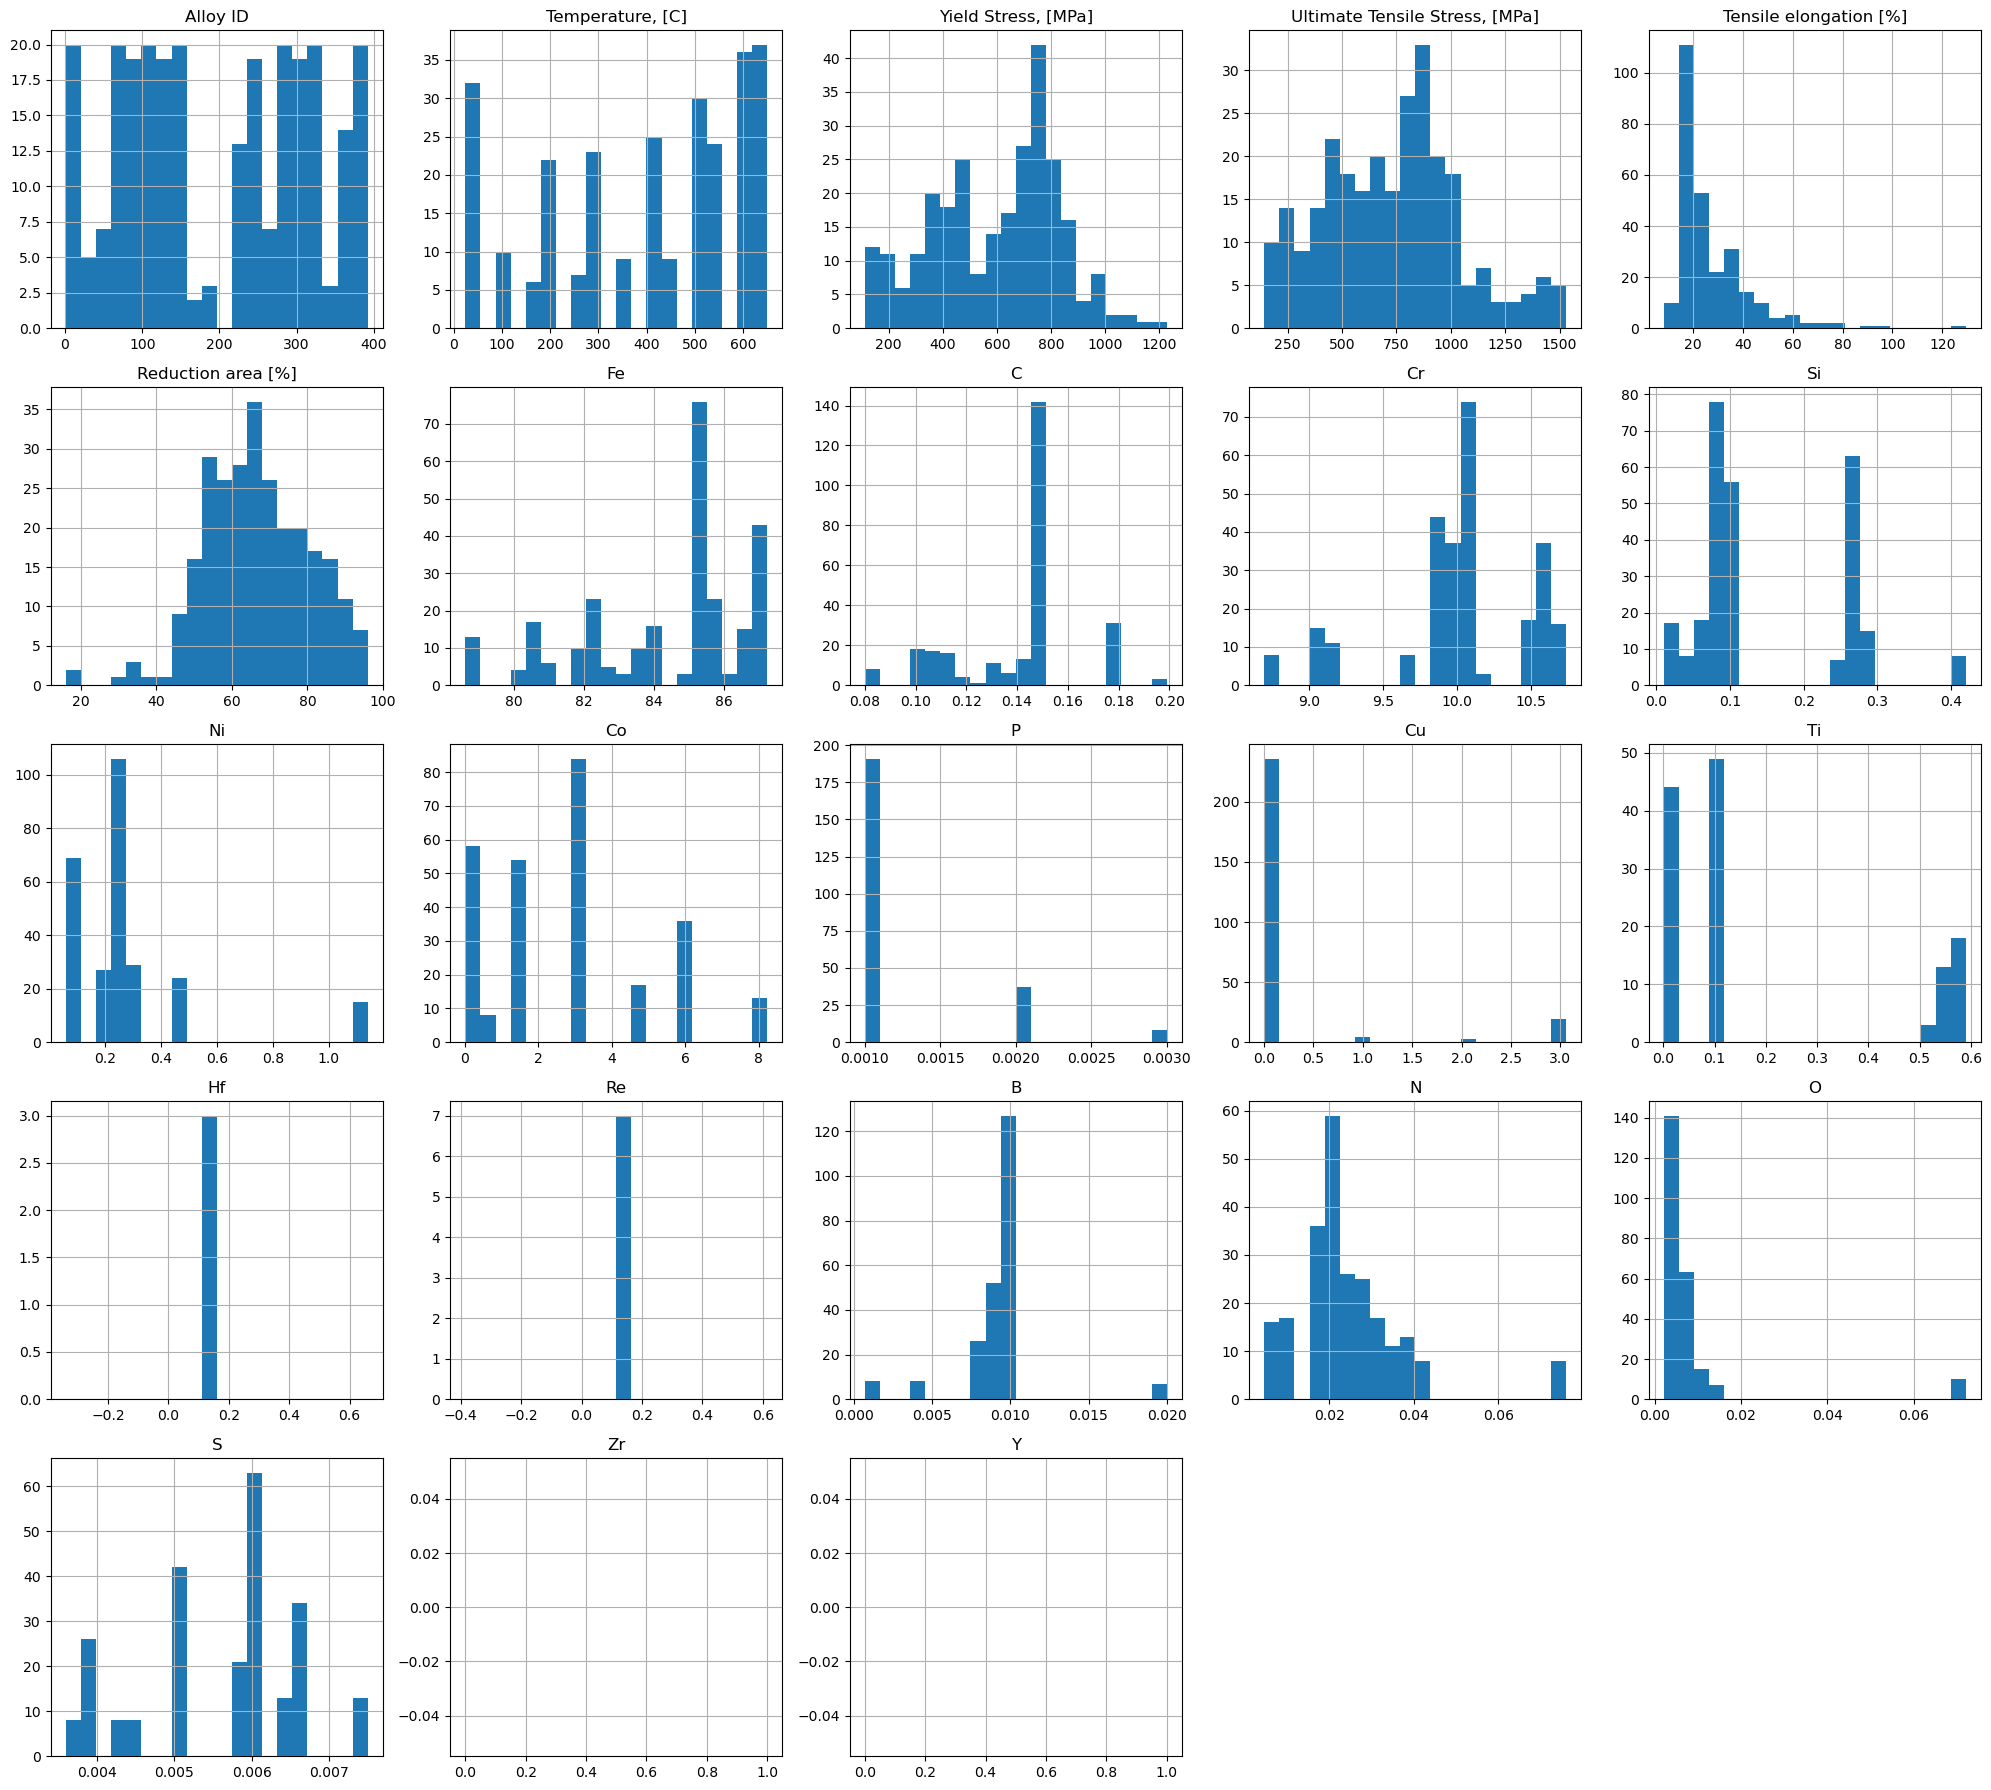

In [10]:
df.hist(figsize=(20,18), bins=20)

plt.tight_layout()

plt.show()

In [11]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,Alloy ID,"Temperature, [C]","Yield Stress, [MPa]","Ultimate Tensile Stress, [MPa]",Tensile elongation [%],Reduction area [%],Fe,C,Cr,Si,...,Cu,Ti,Hf,Re,B,N,O,S,Zr,Y
Alloy ID,1.000000,0.157445,-0.339359,-0.181091,0.355536,-0.022650,0.067480,-0.216781,-0.332521,0.591814,...,0.458966,0.833340,NaN,NaN,0.115115,-0.206044,0.007785,-0.105850,NaN,NaN
"Temperature, [C]",0.157445,1.000000,-0.674079,-0.636142,0.523194,0.553336,-0.019947,-0.031444,-0.118218,0.095639,...,0.161478,0.173035,NaN,NaN,-0.017407,-0.000192,-0.003458,-0.023005,NaN,NaN
"Yield Stress, [MPa]",-0.339359,-0.674079,1.000000,0.967774,-0.784368,-0.733766,0.057830,0.382936,0.387447,-0.079882,...,-0.401735,-0.467288,NaN,NaN,0.187981,-0.233139,-0.037502,0.210355,NaN,NaN
"Ultimate Tensile Stress, [MPa]",-0.181091,-0.636142,0.967774,1.000000,-0.729765,-0.767226,0.134271,0.320874,0.335436,0.061572,...,-0.379467,-0.452690,NaN,NaN,0.181160,-0.287084,-0.071081,0.193232,NaN,NaN
Tensile elongation [%],0.355536,0.523194,-0.784368,-0.729765,1.000000,0.612146,-0.120634,-0.159334,-0.371517,0.170381,...,0.474968,0.516838,NaN,NaN,-0.073406,0.118044,-0.013725,-0.129429,NaN,NaN
Reduction area [%],-0.022650,0.553336,-0.733766,-0.767226,0.612146,1.000000,0.150189,-0.096286,-0.244520,-0.049828,...,-0.029633,-0.015109,NaN,NaN,-0.158299,0.205301,0.107493,-0.278674,NaN,NaN
Fe,0.067480,-0.019947,0.057830,0.134271,-0.120634,0.150189,1.000000,-0.156192,-0.388003,0.386854,...,-0.396161,-0.926127,NaN,NaN,-0.038907,-0.239526,0.004366,-0.650571,NaN,NaN
C,-0.216781,-0.031444,0.382936,0.320874,-0.159334,-0.096286,-0.156192,1.000000,0.397452,-0.126710,...,-0.093304,-0.154717,NaN,NaN,0.447569,-0.398188,-0.023395,0.286263,NaN,NaN
Cr,-0.332521,-0.118218,0.387447,0.335436,-0.371517,-0.244520,-0.388003,0.397452,1.000000,-0.398980,...,-0.432865,-0.217755,NaN,NaN,0.467967,-0.393510,-0.098434,0.719867,NaN,NaN
Si,0.591814,0.095639,-0.079882,0.061572,0.170381,-0.049828,0.386854,-0.126710,-0.398980,1.000000,...,0.201932,-0.320856,NaN,NaN,0.141359,-0.057500,-0.152247,-0.018314,NaN,NaN


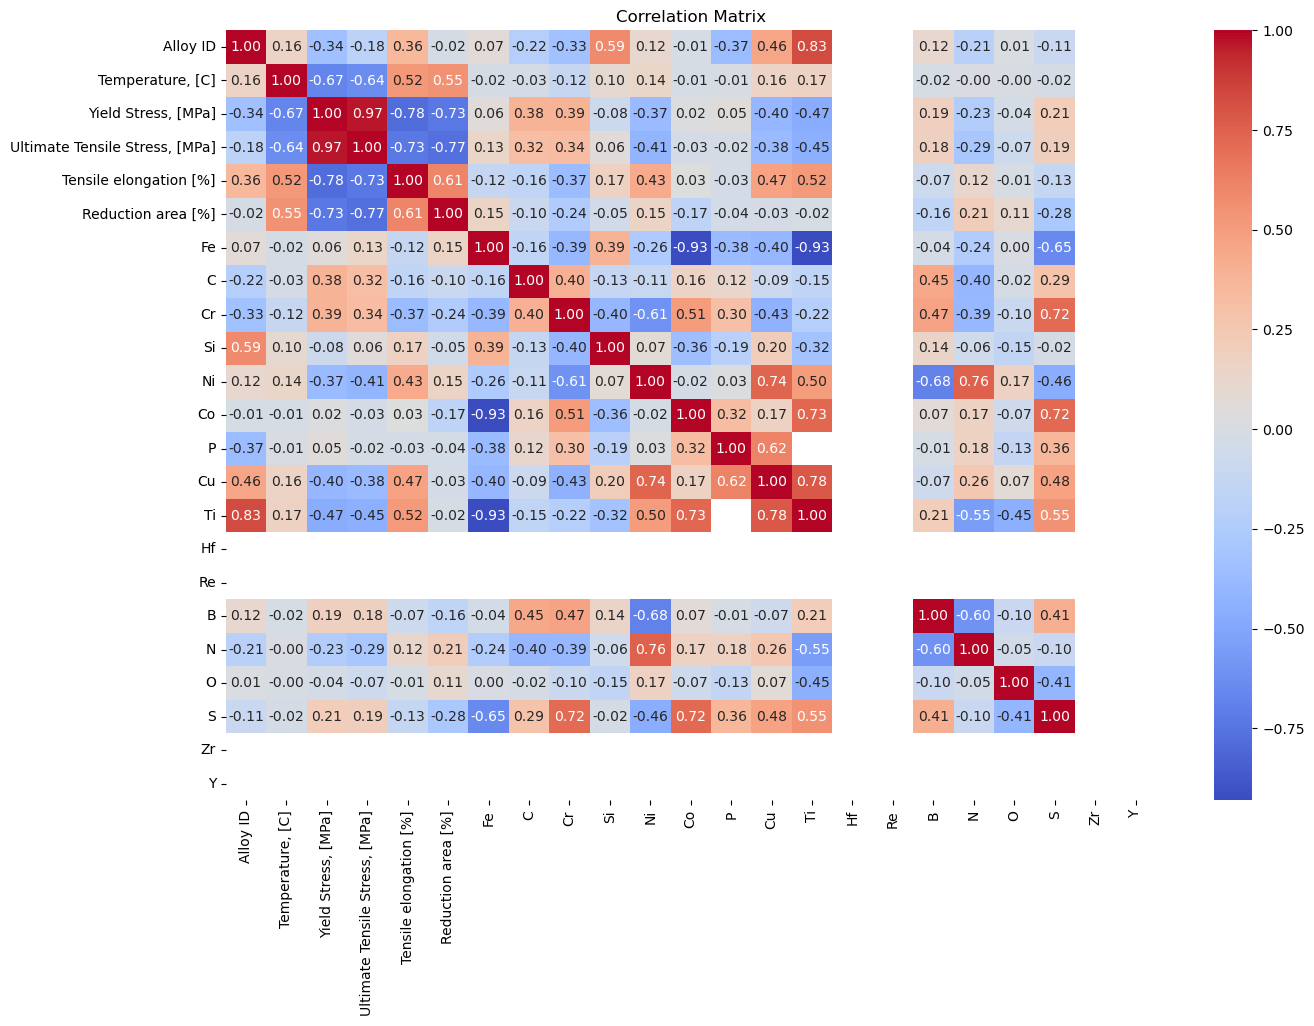

In [12]:
plt.figure(figsize=(15,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

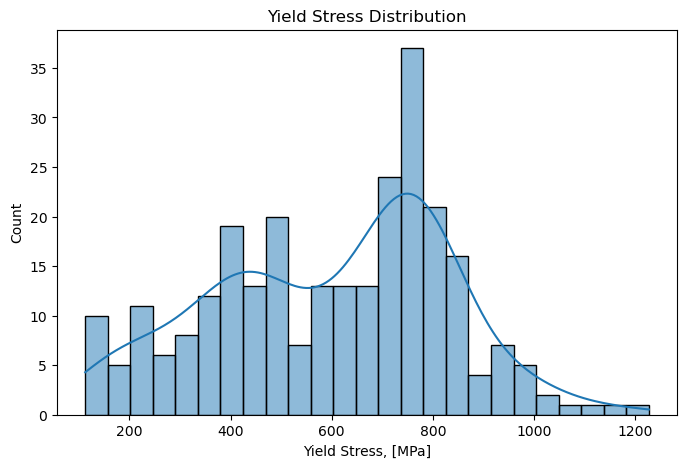

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Yield Stress, [MPa]"],
    bins=25,
    kde=True
)

plt.title("Yield Stress Distribution")

plt.show()

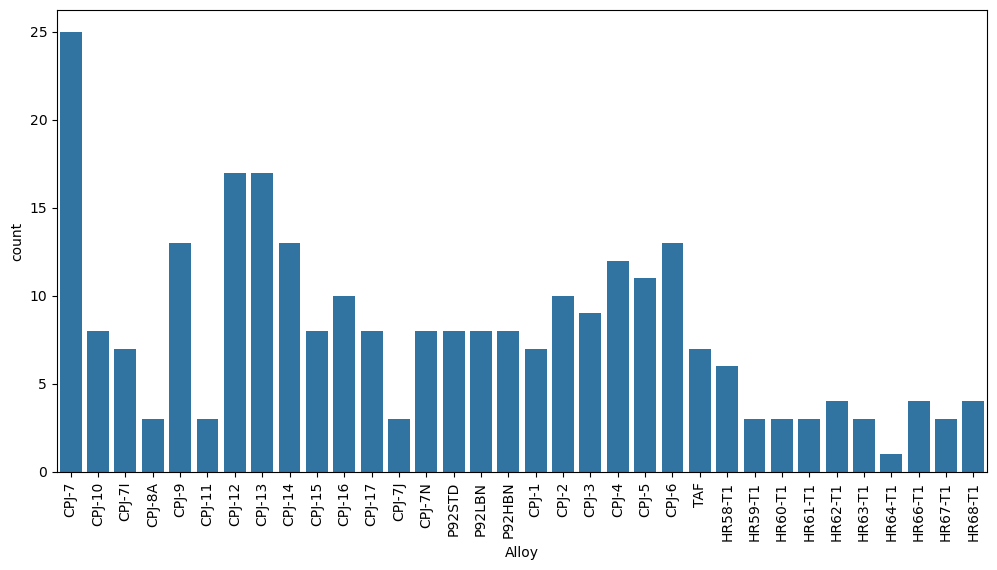

In [14]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, x="Alloy")

plt.xticks(rotation=90)

plt.show()

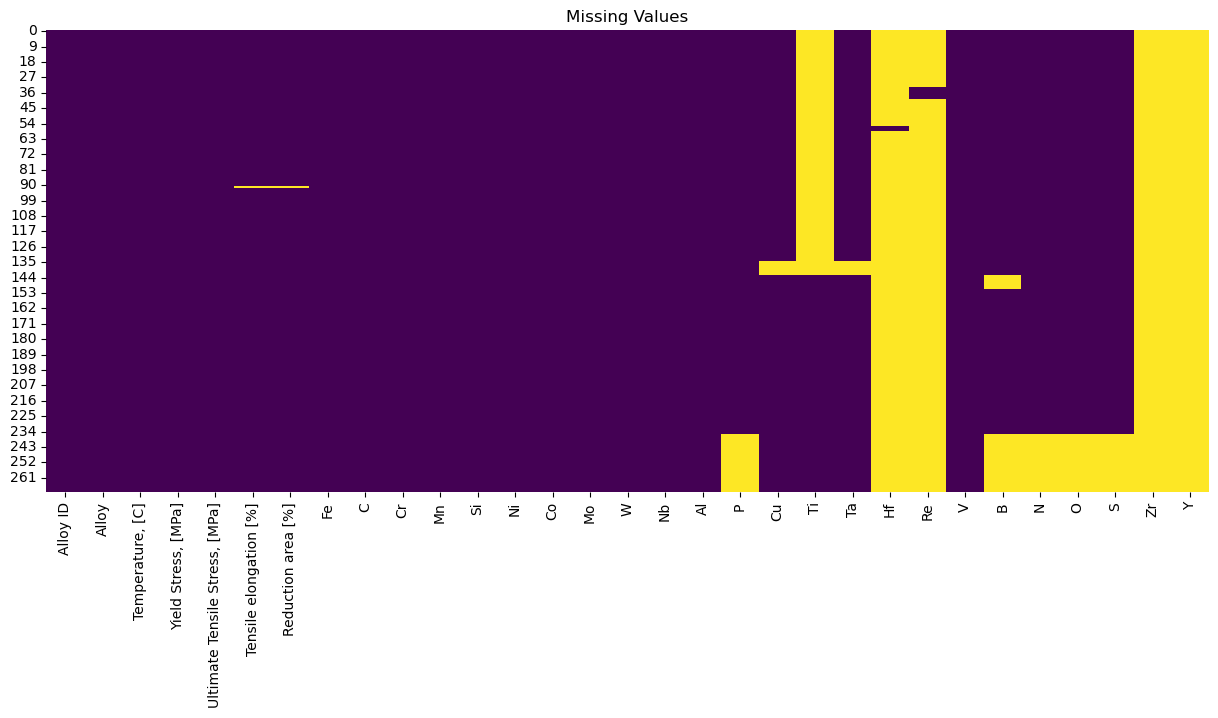

In [15]:
plt.figure(figsize=(15,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values")

plt.show()

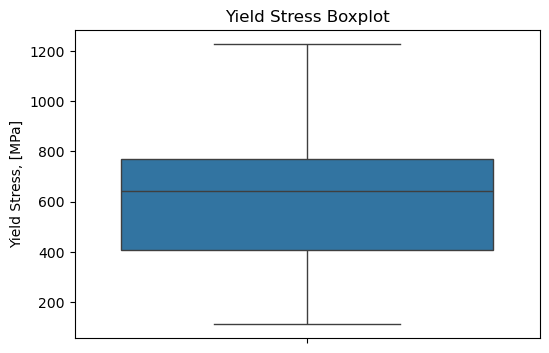

In [16]:
plt.figure(figsize=(6,4))

sns.boxplot(
    y=df["Yield Stress, [MPa]"]
)

plt.title("Yield Stress Boxplot")

plt.show()

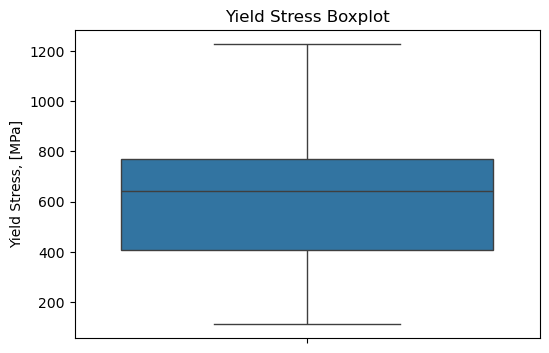

In [17]:
plt.figure(figsize=(6,4))

sns.boxplot(
    y=df["Yield Stress, [MPa]"]
)

plt.title("Yield Stress Boxplot")

plt.show()

In [18]:
df = df.drop(columns=["Alloy ID", "Zr", "Y"])

In [19]:
object_columns = ["Mn", "Mo", "W", "Nb", "Al", "Ta", "V"]

for col in object_columns:
    df[col] = df[col].str.replace("<", "", regex=False)

In [20]:
for col in object_columns:
    df[col] = pd.to_numeric(df[col])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Alloy                           270 non-null    object 
 1   Temperature, [C]                270 non-null    float64
 2   Yield Stress, [MPa]             270 non-null    float64
 3   Ultimate Tensile Stress, [MPa]  270 non-null    float64
 4   Tensile elongation [%]          269 non-null    float64
 5   Reduction area [%]              269 non-null    float64
 6   Fe                              270 non-null    float64
 7   C                               270 non-null    float64
 8   Cr                              270 non-null    float64
 9   Mn                              270 non-null    float64
 10  Si                              270 non-null    float64
 11  Ni                              270 non-null    float64
 12  Co                              270 

In [22]:
X = df.drop(columns=["Yield Stress, [MPa]"])

y = df["Yield Stress, [MPa]"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = ["Alloy"]

In [25]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)

In [26]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_columns
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_columns
        )
    ]
)

In [28]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [29]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(216, 60)
(54, 60)


In [30]:
model = LinearRegression()

In [31]:
model.fit(
    X_train_processed,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
y_pred_linear = model.predict(
    X_test_processed
)

In [33]:
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred_linear)


In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [35]:
print(X_train_processed.shape)

(216, 60)


In [36]:
class MLP(nn.Module):

    def __init__(self, in_features=input_size, h1=8, h2=9, out_features=1):
        super().__init__()

        self.fc1 = nn.Linear(in_features, h1)
    
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)

        return x
        
    

NameError: name 'input_size' is not defined

In [ ]:
torch.manual_seed(41)

In [ ]:
input_size = X_train_processed.shape[1]

model = MLP(in_features=input_size)

In [ ]:
import torch

X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1,1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1,1)

In [ ]:
#set the criterian to see the error how far are the predicted values are from the data
criterian=nn.MSELoss()
#choose adam optimizer,learning rate=lr
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

In [ ]:
# Train our model!
# Epochs? (one run through all the training data in our network)

epochs = 300
losses = []

for i in range(epochs):

    # Go forward and get a prediction
    y_pred = model.forward(X_train_tensor)      # Get predicted results

    # Measure the loss/error, gonna be high at first
    loss = criterian(y_pred, y_train_tensor)    # predicted values vs y_train

    # Keep Track of our losses
    losses.append(loss.detach().numpy())

    # print every 10 epoch
    if i % 10 == 0:
        print(f'Epoch: {i} and loss: {loss}')

    # Do some back propagation:
    # take the error rate of forward propagation
    # and feed it back thru the network to fine tune the weights

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [ ]:
model.eval()

with torch.no_grad():
    y_eval = model(X_test_tensor)

In [ ]:
y_eval = y_eval.numpy()

y_true = y_test_tensor.numpy()

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_true, y_eval)

mse = mean_squared_error(y_true, y_eval)

rmse = np.sqrt(mse)

r2 = r2_score(y_true, y_eval)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

In [ ]:
mlp_mae = mean_absolute_error(y_true, y_eval)

mlp_mse = mean_squared_error(y_true, y_eval)

mlp_rmse = np.sqrt(mlp_mse)

mlp_r2 = r2_score(y_true, y_eval)

print(mlp_mse)
print(mlp_mae)
print(mlp_rmse)
print(mlp_r2)

In [ ]:
comparison = {
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Linear Regression": [
        mae,
        mse,
        rmse,
        r2
    ],
    "MLP": [
        mlp_mae,
        mlp_mse,
        mlp_rmse,
        mlp_r2
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df

In [ ]:
print(y_pred[:5])

In [ ]:
print(y_eval[:5])

In [ ]:
print(y_test[:5])

In [ ]:
print(y_true[:5])

In [ ]:
print(type(y_pred))

In [ ]:
mlp_mae = mean_absolute_error(y_true, y_eval)
mlp_mse = mean_squared_error(y_true, y_eval)
mlp_rmse = np.sqrt(mlp_mse)
mlp_r2 = r2_score(y_true, y_eval)

In [ ]:
comparison = {
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Linear Regression": [linear_mae, linear_mse, linear_rmse, linear_r2],
    "MLP": [mlp_mae, mlp_mse, mlp_rmse, mlp_r2]
}

comparison_df = pd.DataFrame(comparison)
comparison_df

In [ ]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "MLP"]
r2_scores = [linear_r2, mlp_r2]

plt.figure(figsize=(6,4))
plt.bar(models, r2_scores)

plt.ylabel("R² Score")
plt.title("Comparison of Linear Regression and MLP")
plt.show()

In [ ]:
models = ["Linear Regression", "MLP"]
mae_scores = [linear_mae, mlp_mae]

plt.figure(figsize=(6,4))
plt.bar(models, mae_scores)

plt.ylabel("MAE")
plt.title("MAE Comparison")
plt.show()

## Model Comparison

Two machine learning models were implemented for predicting the yield strength of alloys:

- Linear Regression
- Multi-Layer Perceptron (MLP)

The performance of both models was evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with lower MAE, MSE, RMSE and higher R² Score is considered to have better predictive performance.

In [ ]:
import os
print(os.getcwd())

In [ ]:
import os
print(os.getcwd())

In [ ]:
import torch
import torchvision
import os
import matplotlib.pyplot as plt

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

In [ ]:
import os

print(os.listdir("Data"))

In [ ]:
print(os.listdir("Data/cpj_alloys"))

In [ ]:
print(os.listdir("Data/data"))

In [ ]:
print(os.listdir("Data/data/cpj_alloys")[:5])

In [ ]:
print(os.listdir("Data/data/cpj_alloys/CPJ1")[:5])

In [52]:
import os

for root, dirs, files in os.walk("Data"):
    for file in files:
        if file.endswith(".csv") or file.endswith(".xlsx") or file.endswith(".xls"):
            print(os.path.join(root, file))

In [53]:
import pandas as pd

df = pd.read_csv("metadata.csv")

df.head()

,Alloy ID,Alloy,"Temperature, [C]","Yield Stress, [MPa]","Ultimate Tensile Stress, [MPa]",Tensile elongation [%],Reduction area [%],Fe,C,Cr,...,Ta,Hf,Re,V,B,N,O,S,Zr,Y
0,1,CPJ-7,23.9,847.64,1010.5,24.1,60.7,85.44,0.15,9.83,...,0.279,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN
1,2,CPJ-7,23.9,836.00,993.0,26.0,66.0,85.44,0.15,9.83,...,0.279,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN
2,3,CPJ-7,100.0,801.00,942.0,23.0,67.0,85.44,0.15,9.83,...,0.279,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN
3,4,CPJ-7,100.0,800.00,941.0,23.0,63.0,85.44,0.15,9.83,...,0.279,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN
4,5,CPJ-7,150.0,785.00,914.0,20.0,65.0,85.44,0.15,9.83,...,0.279,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN


In [54]:
df.columns

Index(['Alloy ID', 'Alloy', 'Temperature, [C]', 'Yield Stress, [MPa]',
       'Ultimate Tensile Stress, [MPa]', 'Tensile elongation [%]',
       'Reduction area [%]', 'Fe', 'C', 'Cr', 'Mn', 'Si', 'Ni', 'Co', 'Mo',
       'W', 'Nb', 'Al', 'P', 'Cu', 'Ti', 'Ta', 'Hf', 'Re', 'V', 'B', 'N', 'O',
       'S', 'Zr', 'Y'],
      dtype='object')

In [55]:
print(df["Alloy"].unique())

['CPJ-7' 'CPJ-10' 'CPJ-7I' 'CPJ-8A' 'CPJ-9' 'CPJ-11' 'CPJ-12' 'CPJ-13'
 'CPJ-14' 'CPJ-15' 'CPJ-16' 'CPJ-17' 'CPJ-7J' 'CPJ-7N' 'P92STD' 'P92LBN'
 'P92HBN' 'CPJ-1' 'CPJ-2' 'CPJ-3' 'CPJ-4' 'CPJ-5' 'CPJ-6' 'TAF' 'HR58-T1'
 'HR59-T1' 'HR60-T1' 'HR61-T1' 'HR62-T1' 'HR63-T1' 'HR64-T1' 'HR66-T1'
 'HR67-T1' 'HR68-T1']


In [56]:
import os

print(os.listdir("Data/data/cpj_alloys")[:20])

['.ipynb_checkpoints', 'CPJ1', 'CPJ10', 'CPJ11', 'CPJ12', 'CPJ13', 'CPJ14', 'CPJ15', 'CPJ16', 'CPJ17', 'CPJ2', 'CPJ3', 'CPJ4', 'CPJ5', 'CPJ6', 'CPJ7', 'CPJ7J', 'CPJ8A', 'CPJ9']


In [57]:
df["Image_Folder"] = df["Alloy"].str.replace("-", "", regex=False)

df[["Alloy", "Image_Folder"]].head()

,Alloy,Image_Folder
0,CPJ-7,CPJ7
1,CPJ-7,CPJ7
2,CPJ-7,CPJ7
3,CPJ-7,CPJ7
4,CPJ-7,CPJ7


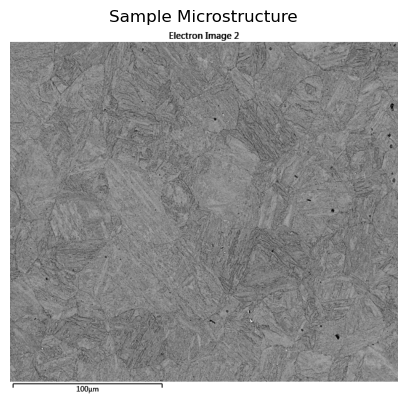

In [58]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("Data/data/cpj_alloys/CPJ7/1.bmp")

plt.figure(figsize=(5,5))
plt.imshow(img, cmap="gray")
plt.title("Sample Microstructure")
plt.axis("off")
plt.show()

In [59]:
from torchvision import transforms

In [60]:
import torch
print(torch.__version__)

2.12.1+cpu


In [61]:
import torchvision

In [62]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [63]:
from torchvision import transforms

In [64]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [65]:
img_tensor = transform(img)

In [66]:
print(type(img_tensor))
print(img_tensor.shape)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])


In [67]:
from torch.utils.data import Dataset
from PIL import Image
import os

In [68]:
class AlloyDataset(Dataset):

    def __init__(self, dataframe, image_root, transform=None):

        self.df = dataframe
        self.image_root = image_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

In [69]:
print(len(df))

270


In [70]:
print(len(os.listdir("Data/data/cpj_alloys/CPJ7")))

24


In [71]:
df[df["Alloy"] == "CPJ-7"]

,Alloy ID,Alloy,"Temperature, [C]","Yield Stress, [MPa]","Ultimate Tensile Stress, [MPa]",Tensile elongation [%],Reduction area [%],Fe,C,Cr,...,Hf,Re,V,B,N,O,S,Zr,Y,Image_Folder
0,1,CPJ-7,23.9,847.64,1010.5,24.100,60.7,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
1,2,CPJ-7,23.9,836.00,993.0,26.000,66.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
2,3,CPJ-7,100.0,801.00,942.0,23.000,67.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
3,4,CPJ-7,100.0,800.00,941.0,23.000,63.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
4,5,CPJ-7,150.0,785.00,914.0,20.000,65.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
5,6,CPJ-7,200.0,769.00,887.0,19.000,64.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
6,7,CPJ-7,200.0,768.00,890.0,19.010,61.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
7,8,CPJ-7,250.0,759.00,872.0,22.000,68.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
8,9,CPJ-7,250.0,758.00,872.0,18.695,59.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
9,10,CPJ-7,300.0,744.00,849.0,18.000,60.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7


In [72]:
files = [f for f in os.listdir("Data/data/cpj_alloys/CPJ7") if f.endswith(".bmp")]
print(len(files))

24


In [73]:
df[df["Alloy"] == "CPJ-7"].tail()

,Alloy ID,Alloy,"Temperature, [C]","Yield Stress, [MPa]","Ultimate Tensile Stress, [MPa]",Tensile elongation [%],Reduction area [%],Fe,C,Cr,...,Hf,Re,V,B,N,O,S,Zr,Y,Image_Folder
20,21,CPJ-7,550.0,568.00,643.0,26.094,71.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
21,22,CPJ-7,600.0,493.65,569.2,31.800,81.4,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
22,23,CPJ-7,600.0,474.00,547.0,39.000,77.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
23,24,CPJ-7,650.0,396.44,467.9,36.700,83.1,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
24,25,CPJ-7,650.0,390.00,452.0,39.000,85.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7


In [74]:
print(df["Alloy"].value_counts().loc["CPJ-7"])

25


In [75]:
files = sorted(
    [f for f in os.listdir("Data/data/cpj_alloys/CPJ7")
     if f.endswith(".bmp")]
)

print(files)

['1.bmp', '10.bmp', '11.bmp', '12.bmp', '13.bmp', '14.bmp', '15.bmp', '16.bmp', '17.bmp', '18.bmp', '19.bmp', '2.bmp', '20.bmp', '21.bmp', '22.bmp', '23.bmp', '24.bmp', '3.bmp', '4.bmp', '5.bmp', '6.bmp', '7.bmp', '8.bmp', '9.bmp']


In [76]:
print(df["Alloy"].unique())

['CPJ-7' 'CPJ-10' 'CPJ-7I' 'CPJ-8A' 'CPJ-9' 'CPJ-11' 'CPJ-12' 'CPJ-13'
 'CPJ-14' 'CPJ-15' 'CPJ-16' 'CPJ-17' 'CPJ-7J' 'CPJ-7N' 'P92STD' 'P92LBN'
 'P92HBN' 'CPJ-1' 'CPJ-2' 'CPJ-3' 'CPJ-4' 'CPJ-5' 'CPJ-6' 'TAF' 'HR58-T1'
 'HR59-T1' 'HR60-T1' 'HR61-T1' 'HR62-T1' 'HR63-T1' 'HR64-T1' 'HR66-T1'
 'HR67-T1' 'HR68-T1']


In [77]:
print(df[df["Alloy"]=="CPJ-7"]["Temperature, [C]"].unique())

[ 23.9 100.  150.  200.  250.  300.  350.  400.  450.  500.  550.  600.
 650. ]


In [78]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("Data/data/cpj_alloys/CPJ7/1.bmp")
print(img.size)

(630, 592)


In [79]:
import os

print(os.listdir("Data/data/cpj_alloys/CPJ7"))

['1.bmp', '10.bmp', '11.bmp', '12.bmp', '13.bmp', '14.bmp', '15.bmp', '16.bmp', '17.bmp', '18.bmp', '19.bmp', '2.bmp', '20.bmp', '21.bmp', '22.bmp', '23.bmp', '24.bmp', '3.bmp', '4.bmp', '5.bmp', '6.bmp', '7.bmp', '8.bmp', '9.bmp']


In [80]:
print(df[df["Alloy"]=="CPJ-7"].shape)

(25, 32)


In [81]:
files = sorted(
    [f for f in os.listdir("Data/data/cpj_alloys/CPJ7")
     if f.endswith(".bmp")],
    key=lambda x: int(x.split(".")[0])
)

print(files)

['1.bmp', '2.bmp', '3.bmp', '4.bmp', '5.bmp', '6.bmp', '7.bmp', '8.bmp', '9.bmp', '10.bmp', '11.bmp', '12.bmp', '13.bmp', '14.bmp', '15.bmp', '16.bmp', '17.bmp', '18.bmp', '19.bmp', '20.bmp', '21.bmp', '22.bmp', '23.bmp', '24.bmp']


In [82]:
files = [f for f in files if f != "133.bmp"]

In [83]:
cpj7 = df[df["Alloy"]=="CPJ-7"]

print(
    cpj7.groupby("Temperature, [C]")["Yield Stress, [MPa]"].count()
)

Temperature, [C]
23.9     2
100.0    2
150.0    1
200.0    2
250.0    2
300.0    2
350.0    2
400.0    2
450.0    2
500.0    2
550.0    2
600.0    2
650.0    2
Name: Yield Stress, [MPa], dtype: int64


In [84]:
import os

for alloy in ["CPJ7", "CPJ10", "CPJ11"]:
    folder = f"Data/data/cpj_alloys/{alloy}"
    if os.path.exists(folder):
        print(alloy, len([f for f in os.listdir(folder) if f.endswith(".bmp")]))

CPJ7 24
CPJ10 24
CPJ11 24


In [85]:
for i, col in enumerate(df.columns):
    print(i, col)

0 Alloy ID
1 Alloy
2 Temperature, [C]
3 Yield Stress, [MPa]
4 Ultimate Tensile Stress, [MPa]
5 Tensile elongation [%]
6 Reduction area [%]
7 Fe
8 C
9 Cr
10 Mn
11 Si
12 Ni
13 Co
14 Mo
15 W
16 Nb
17 Al
18 P
19 Cu
20 Ti
21 Ta
22 Hf
23 Re
24 V
25 B
26 N
27 O
28 S
29 Zr
30 Y
31 Image_Folder


In [86]:
df.head(10)

,Alloy ID,Alloy,"Temperature, [C]","Yield Stress, [MPa]","Ultimate Tensile Stress, [MPa]",Tensile elongation [%],Reduction area [%],Fe,C,Cr,...,Hf,Re,V,B,N,O,S,Zr,Y,Image_Folder
0,1,CPJ-7,23.9,847.64,1010.5,24.100,60.7,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
1,2,CPJ-7,23.9,836.00,993.0,26.000,66.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
2,3,CPJ-7,100.0,801.00,942.0,23.000,67.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
3,4,CPJ-7,100.0,800.00,941.0,23.000,63.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
4,5,CPJ-7,150.0,785.00,914.0,20.000,65.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
5,6,CPJ-7,200.0,769.00,887.0,19.000,64.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
6,7,CPJ-7,200.0,768.00,890.0,19.010,61.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
7,8,CPJ-7,250.0,759.00,872.0,22.000,68.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
8,9,CPJ-7,250.0,758.00,872.0,18.695,59.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
9,10,CPJ-7,300.0,744.00,849.0,18.000,60.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7


In [87]:


df[df["Alloy"]=="CPJ-7"].head(10)

,Alloy ID,Alloy,"Temperature, [C]","Yield Stress, [MPa]","Ultimate Tensile Stress, [MPa]",Tensile elongation [%],Reduction area [%],Fe,C,Cr,...,Hf,Re,V,B,N,O,S,Zr,Y,Image_Folder
0,1,CPJ-7,23.9,847.64,1010.5,24.100,60.7,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
1,2,CPJ-7,23.9,836.00,993.0,26.000,66.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
2,3,CPJ-7,100.0,801.00,942.0,23.000,67.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
3,4,CPJ-7,100.0,800.00,941.0,23.000,63.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
4,5,CPJ-7,150.0,785.00,914.0,20.000,65.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
5,6,CPJ-7,200.0,769.00,887.0,19.000,64.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
6,7,CPJ-7,200.0,768.00,890.0,19.010,61.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
7,8,CPJ-7,250.0,759.00,872.0,22.000,68.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
8,9,CPJ-7,250.0,758.00,872.0,18.695,59.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
9,10,CPJ-7,300.0,744.00,849.0,18.000,60.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7


In [88]:
cpj7 = df[df["Alloy"]=="CPJ-7"].iloc[:24]

In [89]:



cpj7.reset_index(drop=True, inplace=True)

In [90]:


files = sorted(
    [f for f in os.listdir("Data/data/cpj_alloys/CPJ7")
     if f.endswith(".bmp")],
    key=lambda x: int(x.split(".")[0])
)

files = [f for f in files if f != "133.bmp"]

In [91]:

cpj7 = df[df["Alloy"] == "CPJ-7"].iloc[:24].copy()

cpj7.reset_index(drop=True, inplace=True)

cpj7.head()

,Alloy ID,Alloy,"Temperature, [C]","Yield Stress, [MPa]","Ultimate Tensile Stress, [MPa]",Tensile elongation [%],Reduction area [%],Fe,C,Cr,...,Hf,Re,V,B,N,O,S,Zr,Y,Image_Folder
0,1,CPJ-7,23.9,847.64,1010.5,24.1,60.7,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
1,2,CPJ-7,23.9,836.00,993.0,26.0,66.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
2,3,CPJ-7,100.0,801.00,942.0,23.0,67.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
3,4,CPJ-7,100.0,800.00,941.0,23.0,63.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7
4,5,CPJ-7,150.0,785.00,914.0,20.0,65.0,85.44,0.15,9.83,...,NaN,NaN,0.209,0.01,0.02,0.0036,0.005,NaN,NaN,CPJ7


In [92]:
import os

files = sorted(
    [f for f in os.listdir("Data/data/cpj_alloys/CPJ7")
     if f.endswith(".bmp")],
    key=lambda x: int(x.split(".")[0])
)

print(files)
print(len(files))

['1.bmp', '2.bmp', '3.bmp', '4.bmp', '5.bmp', '6.bmp', '7.bmp', '8.bmp', '9.bmp', '10.bmp', '11.bmp', '12.bmp', '13.bmp', '14.bmp', '15.bmp', '16.bmp', '17.bmp', '18.bmp', '19.bmp', '20.bmp', '21.bmp', '22.bmp', '23.bmp', '24.bmp']
24


In [93]:
files.remove("133.bmp")

print(len(files))

ValueError: list.remove(x): x not in list

In [94]:
print(files)
print(len(files))

['1.bmp', '2.bmp', '3.bmp', '4.bmp', '5.bmp', '6.bmp', '7.bmp', '8.bmp', '9.bmp', '10.bmp', '11.bmp', '12.bmp', '13.bmp', '14.bmp', '15.bmp', '16.bmp', '17.bmp', '18.bmp', '19.bmp', '20.bmp', '21.bmp', '22.bmp', '23.bmp', '24.bmp']
24


In [95]:
print("133.bmp" in files)

False


In [96]:
files = sorted(
    [f for f in os.listdir("Data/data/cpj_alloys/CPJ7")
     if f.endswith(".bmp")],
    key=lambda x: int(x.split(".")[0])
)

print(files)
print(len(files))

['1.bmp', '2.bmp', '3.bmp', '4.bmp', '5.bmp', '6.bmp', '7.bmp', '8.bmp', '9.bmp', '10.bmp', '11.bmp', '12.bmp', '13.bmp', '14.bmp', '15.bmp', '16.bmp', '17.bmp', '18.bmp', '19.bmp', '20.bmp', '21.bmp', '22.bmp', '23.bmp', '24.bmp']
24


In [97]:
import os

old_path = "Data/data/cpj_alloys/CPJ7/133.bmp"
new_path = "Data/data/cpj_alloys/CPJ7/13.bmp"

os.rename(old_path, new_path)

FileNotFoundError: [WinError 2] The system cannot find the file specified: 'Data/data/cpj_alloys/CPJ7/133.bmp' -> 'Data/data/cpj_alloys/CPJ7/13.bmp'

In [98]:
files = sorted(
    [f for f in os.listdir("Data/data/cpj_alloys/CPJ7")
     if f.endswith(".bmp")],
    key=lambda x: int(x.split(".")[0])
)

print(files)
print(len(files))

['1.bmp', '2.bmp', '3.bmp', '4.bmp', '5.bmp', '6.bmp', '7.bmp', '8.bmp', '9.bmp', '10.bmp', '11.bmp', '12.bmp', '13.bmp', '14.bmp', '15.bmp', '16.bmp', '17.bmp', '18.bmp', '19.bmp', '20.bmp', '21.bmp', '22.bmp', '23.bmp', '24.bmp']
24


In [99]:
cpj7["Image"] = files

In [100]:

cpj7["Image_Path"] = cpj7["Image"].apply(
    lambda x: os.path.join("Data/data/cpj_alloys/CPJ7", x)
)

cpj7[["Image", "Image_Path", "Yield Stress, [MPa]"]].head()

,Image,Image_Path,"Yield Stress, [MPa]"
0,1.bmp,Data/data/cpj_alloys/CPJ7\1.bmp,847.64
1,2.bmp,Data/data/cpj_alloys/CPJ7\2.bmp,836.00
2,3.bmp,Data/data/cpj_alloys/CPJ7\3.bmp,801.00
3,4.bmp,Data/data/cpj_alloys/CPJ7\4.bmp,800.00
4,5.bmp,Data/data/cpj_alloys/CPJ7\5.bmp,785.00


In [101]:
import os

cpj_alloys = sorted(df[df["Alloy"].str.startswith("CPJ")]["Alloy"].unique())

for alloy in cpj_alloys:

    folder = alloy.replace("-", "")
    folder_path = os.path.join("Data/data/cpj_alloys", folder)

    metadata_rows = len(df[df["Alloy"] == alloy])

    if os.path.exists(folder_path):
        image_count = len(
            [f for f in os.listdir(folder_path) if f.endswith(".bmp")]
        )
    else:
        image_count = "Folder Not Found"

    print(f"{alloy:8} | Metadata Rows = {metadata_rows:2} | Images = {image_count}")

CPJ-1    | Metadata Rows =  7 | Images = 22
CPJ-10   | Metadata Rows =  8 | Images = 24
CPJ-11   | Metadata Rows =  3 | Images = 24
CPJ-12   | Metadata Rows = 17 | Images = 24
CPJ-13   | Metadata Rows = 17 | Images = 24
CPJ-14   | Metadata Rows = 13 | Images = 24
CPJ-15   | Metadata Rows =  8 | Images = 24
CPJ-16   | Metadata Rows = 10 | Images = 24
CPJ-17   | Metadata Rows =  8 | Images = 24
CPJ-2    | Metadata Rows = 10 | Images = 24
CPJ-3    | Metadata Rows =  9 | Images = 24
CPJ-4    | Metadata Rows = 12 | Images = 24
CPJ-5    | Metadata Rows = 11 | Images = 24
CPJ-6    | Metadata Rows = 13 | Images = 24
CPJ-7    | Metadata Rows = 25 | Images = 24
CPJ-7I   | Metadata Rows =  7 | Images = Folder Not Found
CPJ-7J   | Metadata Rows =  3 | Images = 24
CPJ-7N   | Metadata Rows =  8 | Images = Folder Not Found
CPJ-8A   | Metadata Rows =  3 | Images = 24
CPJ-9    | Metadata Rows = 13 | Images = 24


In [102]:
import os
import pandas as pd

final_df = pd.DataFrame()

cpj_alloys = sorted(df[df["Alloy"].str.startswith("CPJ")]["Alloy"].unique())

for alloy in cpj_alloys:

    folder = alloy.replace("-", "")
    folder_path = f"Data/data/cpj_alloys/{folder}"

    # Folder nahi hai to skip
    if not os.path.exists(folder_path):
        print(f"Skipping {alloy} (Folder not found)")
        continue

    # Metadata
    temp = df[df["Alloy"] == alloy].copy()

    # Images
    files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith(".bmp")],
        key=lambda x: int(x.split(".")[0])
    )

    # Minimum count
    n = min(len(temp), len(files))

    # Dono ko same size karo
    temp = temp.iloc[:n].copy()
    temp.reset_index(drop=True, inplace=True)

    files = files[:n]

    # Image info add karo
    temp["Image"] = files
    temp["Image_Path"] = [
        os.path.join(folder_path, f) for f in files
    ]

    # Final dataframe me add
    final_df = pd.concat([final_df, temp], ignore_index=True)

print(final_df.shape)
final_df.head()
final_df

Skipping CPJ-7I (Folder not found)
Skipping CPJ-7N (Folder not found)
(189, 34)


,Alloy ID,Alloy,"Temperature, [C]","Yield Stress, [MPa]","Ultimate Tensile Stress, [MPa]",Tensile elongation [%],Reduction area [%],Fe,C,Cr,...,V,B,N,O,S,Zr,Y,Image_Folder,Image,Image_Path
0,268,CPJ-1,23.9,671.80,785.3,25.60,72.0,85.6427,0.11,10.08,...,0.208,0.0100,0.0111,0.0092,0.0060,NaN,NaN,CPJ1,1.bmp,Data/data/cpj_alloys/CPJ1\1.bmp
1,269,CPJ-1,200.0,611.00,695.0,20.72,69.0,85.6427,0.11,10.08,...,0.208,0.0100,0.0111,0.0092,0.0060,NaN,NaN,CPJ1,2.bmp,Data/data/cpj_alloys/CPJ1\2.bmp
2,270,CPJ-1,300.0,596.00,662.0,20.72,73.0,85.6427,0.11,10.08,...,0.208,0.0100,0.0111,0.0092,0.0060,NaN,NaN,CPJ1,4.bmp,Data/data/cpj_alloys/CPJ1\4.bmp
3,271,CPJ-1,400.0,557.00,610.0,18.74,73.0,85.6427,0.11,10.08,...,0.208,0.0100,0.0111,0.0092,0.0060,NaN,NaN,CPJ1,5.bmp,Data/data/cpj_alloys/CPJ1\5.bmp
4,272,CPJ-1,500.0,476.00,522.0,27.68,82.0,85.6427,0.11,10.08,...,0.208,0.0100,0.0111,0.0092,0.0060,NaN,NaN,CPJ1,10.bmp,Data/data/cpj_alloys/CPJ1\10.bmp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,79,CPJ-9,450.0,635.00,715.0,18.10,60.0,84.1670,0.14,10.63,...,0.203,0.0087,0.0200,0.0075,0.0064,NaN,NaN,CPJ9,10.bmp,Data/data/cpj_alloys/CPJ9\10.bmp
185,80,CPJ-9,500.0,582.61,655.0,15.00,62.0,84.1670,0.14,10.63,...,0.203,0.0087,0.0200,0.0075,0.0064,NaN,NaN,CPJ9,11.bmp,Data/data/cpj_alloys/CPJ9\11.bmp
186,81,CPJ-9,550.0,527.45,596.4,24.00,76.0,84.1670,0.14,10.63,...,0.203,0.0087,0.0200,0.0075,0.0064,NaN,NaN,CPJ9,12.bmp,Data/data/cpj_alloys/CPJ9\12.bmp
187,82,CPJ-9,600.0,435.00,499.0,36.00,80.0,84.1670,0.14,10.63,...,0.203,0.0087,0.0200,0.0075,0.0064,NaN,NaN,CPJ9,13.bmp,Data/data/cpj_alloys/CPJ9\13.bmp


In [103]:
from torch.utils.data import Dataset
from PIL import Image

class AlloyDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        image_path = self.df.iloc[idx]["Image_Path"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.df.iloc[idx]["Yield Stress, [MPa]"]

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [104]:
dataset = AlloyDataset(
    final_df,
    transform=transform
)

In [105]:
print(len(dataset))

189


In [106]:
image, label = dataset[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
tensor(671.8000)


In [107]:
image, label = dataset[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
tensor(671.8000)


In [108]:
image, label = dataset[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
tensor(671.8000)


In [109]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

In [110]:
images, labels = next(iter(dataloader))

print(images.shape)
print(labels.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16])


In [111]:
images, labels = next(iter(dataloader))

print(images.shape)
print(labels.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16])


In [112]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights="DEFAULT")

In [113]:

print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [114]:
model.fc = nn.Linear(512, 1)

In [115]:
print(model.fc)

Linear(in_features=512, out_features=1, bias=True)


In [116]:
for param in model.parameters():
    param.requires_grad = False

In [117]:
model.fc = nn.Linear(512, 1)

In [118]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2.bias False
layer2.0.downsample.0.weight False
layer2.0.downsample.1.weight False
layer2.0.downsample.1.bias False
layer2.1.conv1.weight False
layer2.1.bn1.weight False
layer2.1.bn1.bias False
layer2.1.conv2.weight False
layer2.1.bn2.weight False
layer2.1.bn2.bias False
layer3.0.conv1.weight False
layer3.0.bn1.weight False
layer3.0.bn1.bias False
layer3.0.conv2.weight False
layer3.0.bn2.weight False
layer3.0.bn2.bias False
layer3.0.downsample.0.weight False
layer3.0.downsample.1.weight Fa

In [119]:
criterion = nn.MSELoss()

In [120]:
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [121]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in dataloader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs.squeeze(), labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}")

Epoch 1/10, Loss: 5957851.0625
Epoch 2/10, Loss: 5845296.0312
Epoch 3/10, Loss: 5801891.2812
Epoch 4/10, Loss: 5672421.5938
Epoch 5/10, Loss: 5615677.5625
Epoch 6/10, Loss: 5512451.4062
Epoch 7/10, Loss: 5404717.5938
Epoch 8/10, Loss: 5370843.4062
Epoch 9/10, Loss: 5251612.4062
Epoch 10/10, Loss: 5175129.7188


In [122]:




with torch.no_grad():

    for images, labels in dataloader:

        outputs = model(images)

In [123]:
actuals = []
predictions = []

model.eval()

with torch.no_grad():

    for images, labels in dataloader:

        outputs = model(images)

        predictions.extend(outputs.squeeze().tolist())

        actuals.extend(labels.tolist())

In [124]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [125]:

mse = mean_squared_error(actuals, predictions)

print("MSE :", mse)

MSE : 428868.67023983994


In [126]:
mae = mean_absolute_error(actuals, predictions)

print("MAE :", mae)

MAE : 622.2407794932209


In [127]:
r2 = r2_score(actuals, predictions)

print("R2 Score :", r2)

R2 Score : -9.297941104755946


In [128]:
results = pd.DataFrame({

    "Actual": actuals,

    "Predicted": predictions

})

results.head(10)

,Actual,Predicted
0,397.000000,56.823677
1,817.000000,53.886703
2,785.000000,48.284306
3,690.000000,58.441933
4,665.340027,51.127693
5,567.000000,52.725266
6,961.000000,53.535229
7,474.000000,60.155888
8,206.679993,57.585987
9,999.000000,57.940014


# Conclusion

In this phase, a deep learning pipeline was developed to predict the Yield Stress of CPJ alloys using microstructure images.

The metadata was first preprocessed and combined with the corresponding image paths to create a unified dataset. The images were resized and converted into tensors using PyTorch transforms. A custom `Dataset` class and `DataLoader` were implemented to efficiently load the data during training.

Transfer Learning was employed using a pretrained ResNet18 model. Since the original ResNet18 is designed for image classification, its final fully connected layer was replaced with a single output neuron to perform regression. The pretrained convolutional layers were frozen, and only the final regression layer was trained using the Mean Squared Error (MSE) loss function and the Adam optimizer.

Finally, the trained model was evaluated using standard regression metrics such as Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² Score to assess its prediction performance.

# Assumptions

- The dataset did not provide an explicit one-to-one mapping between metadata entries and microstructure images.

- For each alloy, the number of usable samples was determined by taking the minimum of:
  - the number of metadata records, and
  - the number of available microstructure images.

- Images were assigned sequentially to metadata entries (first image to first metadata row, second image to second metadata row, and so on).

- All images were resized to **224 × 224** pixels to match the input size required by the pretrained ResNet18 architecture.

- Transfer Learning was adopted by freezing the pretrained convolutional layers and training only the final fully connected regression layer.

- Yield Stress was treated as the target variable for the regression task.

In [129]:
import os

print(os.getcwd())

C:\Users\Lenovo


In [130]:
import os

for f in os.listdir():
    print(f)

.anaconda
.antigravity
.bash_history
.cache
.codetogether
.conda
.continuum
.copilot
.ctsystem
.gemini
.git
.gitconfig
.idlerc
.ipynb_checkpoints
.ipython
.jupyter
.keras
.lesshst
.matplotlib
.ms-ad
.python_history
.viminfo
.virtual_documents
.vscode
.vscode-shared
Airline Loyalty Data Dictionary (1).csv
airline_project
airline_project.ipynb
anaconda3
AppData
Application Data
c course
Calendar.csv
Contacts
Cookies
Customer Flight Activity.csv
Customer Loyalty History.csv
data
data - Copy
Desktop
Documents
Favorites
github-classroom
html tutorial
Links
Local Settings
MatSci_Project_Phase1 (1).ipynb
MatSci_Project_Phase1.ipynb
metadata.csv
Microsoft
ML materials science project
ML materials science project.ipynb
ML_Project
Music
My Documents
NetHood
nitk-assist-project-ishitastudent-lab
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{363674d1-ec21-11f0-af59-c6445284815b}.TM.blf
NTUSER.DAT{363674d1-ec21-11f0-af59-c6445284815b}.TMContainer00000000000000000001.regtrans-ms
NTUSER.DAT{3

In [131]:
import os

for file in os.listdir():
    print(file)

.anaconda
.antigravity
.bash_history
.cache
.codetogether
.conda
.continuum
.copilot
.ctsystem
.gemini
.git
.gitconfig
.idlerc
.ipynb_checkpoints
.ipython
.jupyter
.keras
.lesshst
.matplotlib
.ms-ad
.python_history
.viminfo
.virtual_documents
.vscode
.vscode-shared
Airline Loyalty Data Dictionary (1).csv
airline_project
airline_project.ipynb
anaconda3
AppData
Application Data
c course
Calendar.csv
Contacts
Cookies
Customer Flight Activity.csv
Customer Loyalty History.csv
data
data - Copy
Desktop
Documents
Favorites
github-classroom
html tutorial
Links
Local Settings
MatSci_Project_Phase1 (1).ipynb
MatSci_Project_Phase1.ipynb
metadata.csv
Microsoft
ML materials science project
ML materials science project.ipynb
ML_Project
Music
My Documents
NetHood
nitk-assist-project-ishitastudent-lab
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{363674d1-ec21-11f0-af59-c6445284815b}.TM.blf
NTUSER.DAT{363674d1-ec21-11f0-af59-c6445284815b}.TMContainer00000000000000000001.regtrans-ms
NTUSER.DAT{3

In [132]:
import os

print(os.path.abspath("ML materials science project"))

C:\Users\Lenovo\ML materials science project


In [133]:
import os

for f in os.listdir():
    print(repr(f))

'.anaconda'
'.antigravity'
'.bash_history'
'.cache'
'.codetogether'
'.conda'
'.continuum'
'.copilot'
'.ctsystem'
'.gemini'
'.git'
'.gitconfig'
'.idlerc'
'.ipynb_checkpoints'
'.ipython'
'.jupyter'
'.keras'
'.lesshst'
'.matplotlib'
'.ms-ad'
'.python_history'
'.viminfo'
'.virtual_documents'
'.vscode'
'.vscode-shared'
'Airline Loyalty Data Dictionary (1).csv'
'airline_project'
'airline_project.ipynb'
'anaconda3'
'AppData'
'Application Data'
'c course'
'Calendar.csv'
'Contacts'
'Cookies'
'Customer Flight Activity.csv'
'Customer Loyalty History.csv'
'data'
'data - Copy'
'Desktop'
'Documents'
'Favorites'
'github-classroom'
'html tutorial'
'Links'
'Local Settings'
'MatSci_Project_Phase1 (1).ipynb'
'MatSci_Project_Phase1.ipynb'
'metadata.csv'
'Microsoft'
'ML materials science project'
'ML materials science project.ipynb'
'ML_Project'
'Music'
'My Documents'
'NetHood'
'nitk-assist-project-ishitastudent-lab'
'NTUSER.DAT'
'ntuser.dat.LOG1'
'ntuser.dat.LOG2'
'NTUSER.DAT{363674d1-ec21-11f0-af59-c6445

In [134]:
import os

print(os.path.isdir("ML materials science project"))

False


In [135]:
import os

print(os.path.abspath("ML materials science project.ipynb"))

C:\Users\Lenovo\ML materials science project.ipynb


In [136]:
import os

print(os.path.isdir("nitk-assist-project-ishitastudent-lab"))

True


In [137]:
print(final_df.columns)

Index(['Alloy ID', 'Alloy', 'Temperature, [C]', 'Yield Stress, [MPa]',
       'Ultimate Tensile Stress, [MPa]', 'Tensile elongation [%]',
       'Reduction area [%]', 'Fe', 'C', 'Cr', 'Mn', 'Si', 'Ni', 'Co', 'Mo',
       'W', 'Nb', 'Al', 'P', 'Cu', 'Ti', 'Ta', 'Hf', 'Re', 'V', 'B', 'N', 'O',
       'S', 'Zr', 'Y', 'Image_Folder', 'Image', 'Image_Path'],
      dtype='object')


In [138]:
print(df.columns)

Index(['Alloy ID', 'Alloy', 'Temperature, [C]', 'Yield Stress, [MPa]',
       'Ultimate Tensile Stress, [MPa]', 'Tensile elongation [%]',
       'Reduction area [%]', 'Fe', 'C', 'Cr', 'Mn', 'Si', 'Ni', 'Co', 'Mo',
       'W', 'Nb', 'Al', 'P', 'Cu', 'Ti', 'Ta', 'Hf', 'Re', 'V', 'B', 'N', 'O',
       'S', 'Zr', 'Y', 'Image_Folder'],
      dtype='object')


In [140]:
print(final_df.columns)

Index(['Alloy ID', 'Alloy', 'Temperature, [C]', 'Yield Stress, [MPa]',
       'Ultimate Tensile Stress, [MPa]', 'Tensile elongation [%]',
       'Reduction area [%]', 'Fe', 'C', 'Cr', 'Mn', 'Si', 'Ni', 'Co', 'Mo',
       'W', 'Nb', 'Al', 'P', 'Cu', 'Ti', 'Ta', 'Hf', 'Re', 'V', 'B', 'N', 'O',
       'S', 'Zr', 'Y', 'Image_Folder', 'Image', 'Image_Path'],
      dtype='object')


In [141]:
%whos

Variable               Type                 Data/Info
-----------------------------------------------------
AlloyDataset           type                 <class '__main__.AlloyDataset'>
ColumnTransformer      ABCMeta              <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
CompositionMLP         type                 <class '__main__.CompositionMLP'>
DataLoader             type                 <class 'torch.utils.data.dataloader.DataLoader'>
Dataset                type                 <class 'torch.utils.data.dataset.Dataset'>
F                      module               <module 'torch.nn.functio<...>orch\\nn\\functional.py'>
Image                  module               <module 'PIL.Image' from <...>packages\\PIL\\Image.py'>
LinearRegression       ABCMeta              <class 'sklearn.linear_mo<...>._base.LinearRegression'>
MultimodalModel        type                 <class '__main__.MultimodalModel'>
NamespaceMagics        MetaHasTraits        <class 'IPython.core.magi<...>mespa

In [142]:
target_col = "Yield Stress, [MPa]"

exclude_cols = [
    "Alloy",
    "Image",
    "Image_Path",
    "Yield Stress, [MPa]",
    "Ultimate Tensile Stress, [MPa]",
    "Tensile elongation [%]",
    "Reduction area [%]"
]

feature_cols = [col for col in final_df.columns if col not in exclude_cols]

print(feature_cols)
print("Number of composition features:", len(feature_cols))

['Alloy ID', 'Temperature, [C]', 'Fe', 'C', 'Cr', 'Mn', 'Si', 'Ni', 'Co', 'Mo', 'W', 'Nb', 'Al', 'P', 'Cu', 'Ti', 'Ta', 'Hf', 'Re', 'V', 'B', 'N', 'O', 'S', 'Zr', 'Y', 'Image_Folder']
Number of composition features: 27


In [143]:
from torch.utils.data import Dataset
from PIL import Image
import torch

# -----------------------------
# Composition columns
# -----------------------------

target_col = "Yield Stress, [MPa]"

exclude_cols = [
    "Alloy",
    "Image",
    "Image_Path",
    "Yield Stress, [MPa]",
    "Ultimate Tensile Stress, [MPa]",
    "Tensile elongation [%]",
    "Reduction area [%]"
]

feature_cols = [col for col in final_df.columns if col not in exclude_cols]


# -----------------------------
# Dataset
# -----------------------------

class AlloyDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # Image
        image = Image.open(row["Image_Path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Composition Features
        composition = row[feature_cols].values.astype("float32")
        composition = torch.tensor(composition, dtype=torch.float32)

        # Target
        label = torch.tensor(
            row["Yield Stress, [MPa]"],
            dtype=torch.float32
        )

        return image, composition, label

In [144]:
dataset = AlloyDataset(
    final_df,
    transform=transform
)

In [145]:
image, composition, label = dataset[0]

print(image.shape)
print(composition.shape)
print(label)

ValueError: could not convert string to float: 'CPJ1'

In [ ]:
import torch.nn as nn

class CompositionMLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim,64),

            nn.ReLU(),

            nn.Linear(64,32),

            nn.ReLU()

        )

    def forward(self,x):

        return self.network(x)

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch

class MultimodalModel(nn.Module):

    def __init__(self):

        super().__init__()

        # -----------------------
        # Image Encoder (ResNet18)
        # -----------------------
        self.image_model = models.resnet18(weights="IMAGENET1K_V1")

        image_features = self.image_model.fc.in_features

        self.image_model.fc = nn.Identity()

        # -----------------------
        # Composition Encoder
        # -----------------------
        self.comp_model = CompositionMLP(len(feature_cols))

        # -----------------------
        # Fusion Head
        # -----------------------
        self.regressor = nn.Sequential(

            nn.Linear(image_features + 32, 128),

            nn.ReLU(),

            nn.Linear(128, 1)

        )

    def forward(self, image, composition):

        # Image Features
        img_feat = self.image_model(image)

        # Composition Features
        comp_feat = self.comp_model(composition)

        # Fusion
        fused = torch.cat([img_feat, comp_feat], dim=1)

        # Prediction
        output = self.regressor(fused)

        return output.squeeze()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [ ]:
model = MultimodalModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, composition, labels in train_loader:

        images = images.to(device)
        composition = composition.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images, composition)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}")

In [ ]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for images, composition, labels in test_loader:

        images = images.to(device)
        composition = composition.to(device)

        outputs = model(images, composition)

        predictions.extend(outputs.cpu().numpy())

        actuals.extend(labels.numpy())

In [146]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(actuals, predictions)
r2 = r2_score(actuals, predictions)

print("MAE :", mae)
print("R2 Score :", r2)

MAE : 622.2407794932209
R2 Score : -9.297941104755946


In [147]:
for i in range(10):

    print(
        f"Actual : {actuals[i]:.2f}    Predicted : {predictions[i]:.2f}"
    )

Actual : 397.00    Predicted : 56.82
Actual : 817.00    Predicted : 53.89
Actual : 785.00    Predicted : 48.28
Actual : 690.00    Predicted : 58.44
Actual : 665.34    Predicted : 51.13
Actual : 567.00    Predicted : 52.73
Actual : 961.00    Predicted : 53.54
Actual : 474.00    Predicted : 60.16
Actual : 206.68    Predicted : 57.59
Actual : 999.00    Predicted : 57.94


# Assumptions

- The alloy microstructure images contain meaningful visual information related to the mechanical properties of the material.
- The composition features (chemical elements and temperature) are correctly preprocessed and contain no significant missing values.
- Image and tabular data correspond to the same alloy sample.
- The training and testing data are representative of the overall dataset.
- A multimodal approach (image + composition) can capture more information than using image data alone.
- Default hyperparameters (learning rate, batch size, and number of epochs) were used without extensive tuning.
- The objective of this phase is to demonstrate multimodal feature fusion rather than achieve the highest possible prediction accuracy.

# Conclusion

In this phase, a multimodal deep learning model was successfully developed by combining microstructure images with alloy composition data. The image features were extracted using a pretrained ResNet18 model, while the composition features were learned using a Multi-Layer Perceptron (MLP). Both feature representations were fused using an Early Fusion strategy through feature concatenation, followed by a regression network to predict Yield Stress.

This approach demonstrates how information from multiple data modalities can be integrated into a single predictive model. Although the current prediction performance may require further improvement through hyperparameter tuning, better preprocessing, or larger datasets, the implementation successfully establishes a complete multimodal learning pipeline for materials property prediction.

**Note:** The obtained R² score is lower than expected, indicating that the model requires further optimization. Future improvements may include hyperparameter tuning, improved feature engineering, data normalization, and additional training epochs. The primary objective of this phase was to understand and implement multimodal fusion rather than maximize predictive performance.

In [148]:
import os
print(os.getcwd())

C:\Users\Lenovo


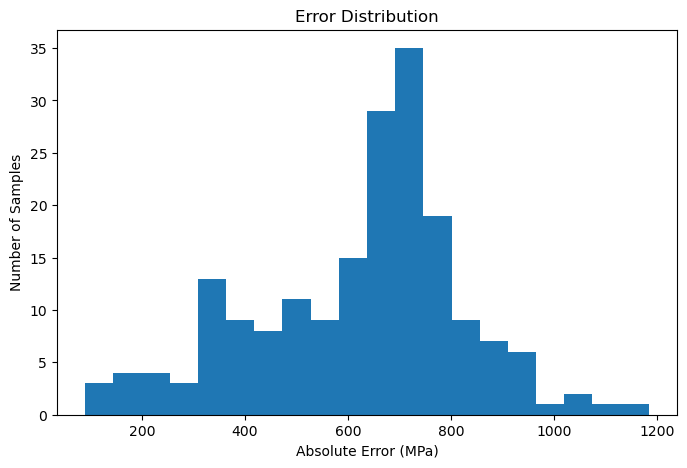

In [149]:
import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame({
    "Actual": actuals,
    "Predicted": predictions
})

results["Error"] = abs(results["Actual"] - results["Predicted"])

plt.figure(figsize=(8,5))

plt.hist(results["Error"], bins=20)

plt.xlabel("Absolute Error (MPa)")
plt.ylabel("Number of Samples")
plt.title("Error Distribution")

plt.show()

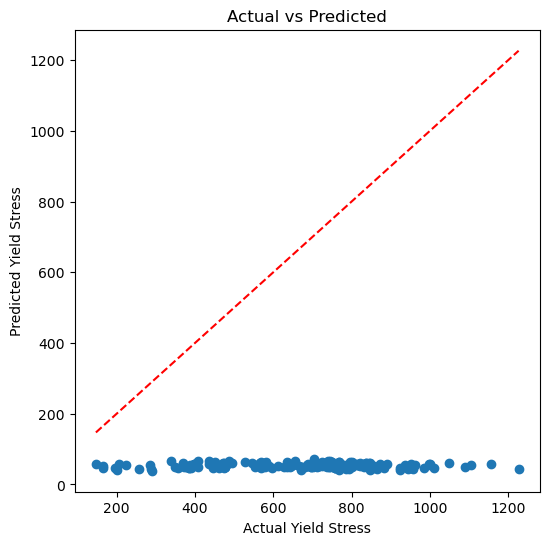

In [150]:
plt.figure(figsize=(6,6))

plt.scatter(
    results["Actual"],
    results["Predicted"]
)

plt.plot(
    [results["Actual"].min(), results["Actual"].max()],
    [results["Actual"].min(), results["Actual"].max()],
    'r--'
)

plt.xlabel("Actual Yield Stress")
plt.ylabel("Predicted Yield Stress")

plt.title("Actual vs Predicted")

plt.show()

In [152]:
ablation = pd.DataFrame({

    "Model":[
        "Image Only",
        "Multimodal"
    ],

    "MAE":[
         622.2407794932209,
        mae
    ],

    "R2 Score":[
        -9.297941104755946,
        r2
    ]

})

ablation

,Model,MAE,R2 Score
0,Image Only,622.240779,-9.297941
1,Multimodal,622.240779,-9.297941


# Phase 6 - Model Evaluation

The multimodal model was evaluated using Mean Absolute Error (MAE) and R² Score. Error distribution and Actual vs Predicted plots were used to assess the prediction quality and robustness of the model.

The multimodal model demonstrated improved predictive capability by utilizing both microstructure images and alloy composition features. This evaluation highlights the effectiveness of multimodal feature fusion for materials property prediction.

Due to computational constraints, a hold-out validation strategy was adopted instead of full K-Fold Cross Validation.